# 01 - Análisis exploratorio (EDA)

Demanda **diaria** peninsular + temperatura (HDD18 / CDD22), 2015-01-01 a 2025-12-31.

**Objetivo:** entender estacionalidad (semanal y anual), tendencia, no-estacionariedad, relación con temperatura y la anomalía COVID antes de modelar.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
df = (
    pd.read_csv(ROOT / 'data' / 'processed' / 'dataset_diario.csv', parse_dates=['fecha'])
      .set_index('fecha')
      .asfreq('D')
)
print('Shape:', df.shape, '  Periodo:', df.index.min().date(), '->', df.index.max().date())
df.head()

## 1. Vista general de la serie

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
(df['demanda_MWh'] / 1e3).plot(ax=ax, color='steelblue', linewidth=0.6)
ax.set_title('Demanda diaria peninsular')
ax.set_ylabel('GWh')
ax.axvspan('2020-03-01', '2020-06-30', color='red', alpha=0.15, label='Confinamiento COVID')
ax.legend(loc='lower left')
plt.tight_layout()

## 2. Descomposición STL

Separa la serie en tendencia + estacionalidad + residuo. STL con `robust=True` es resistente a outliers (útil porque tenemos COVID).

Se usa `period=365` para capturar la estacionalidad **anual** de la serie diaria.

In [ ]:
stl = STL(df['demanda_MWh'], period=365, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(13, 9)
plt.tight_layout()

## 3. ACF y PACF

Para orientar los órdenes de SARIMA. Con estacionalidad **semanal** (7) esperamos picos a lag 7, 14, 21.
Con estacionalidad **anual** veremos estructura en lags ~365.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
plot_acf(df['demanda_MWh'], lags=60, ax=axes[0])
axes[0].set_title('ACF - serie original (60 dias)')
plot_pacf(df['demanda_MWh'], lags=60, ax=axes[1], method='ywm')
axes[1].set_title('PACF - serie original (60 dias)')
plt.tight_layout()

## 4. Tests de estacionariedad

- **ADF** (H0: hay raíz unitaria → no estacionaria). p < 0.05 ⇒ estacionaria.
- **KPSS** (H0: estacionaria). p > 0.05 ⇒ estacionaria.

Ambos tests a la vez son más fiables que uno solo.

In [ ]:
import warnings

def test_estacionariedad(serie, etiqueta):
    s = serie.dropna()
    adf_p = adfuller(s, autolag='AIC')[1]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_p = kpss(s, regression='c', nlags='auto')[1]
    veredicto_adf  = 'estacionaria' if adf_p  < 0.05 else 'NO estacionaria'
    veredicto_kpss = 'estacionaria' if kpss_p > 0.05 else 'NO estacionaria'
    print(f'{etiqueta:35} ADF p={adf_p:.4f} ({veredicto_adf})   KPSS p={kpss_p:.4f} ({veredicto_kpss})')

y = df['demanda_MWh']
test_estacionariedad(y,                    'Original')
test_estacionariedad(y.diff(1),            'd=1')
test_estacionariedad(y.diff(7),            'D=1 (estacional semanal, lag-7)')
test_estacionariedad(y.diff(7).diff(1),    'd=1 + D=1 (semanal)')

In [ ]:
# ACF/PACF tras la diferenciacion que mejor estacionarice
y_diff = df['demanda_MWh'].diff(7).diff(1).dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
plot_acf(y_diff, lags=60, ax=axes[0])
axes[0].set_title('ACF tras d=1, D=1 (semanal)')
plot_pacf(y_diff, lags=60, ax=axes[1], method='ywm')
axes[1].set_title('PACF tras d=1, D=1 (semanal)')
plt.tight_layout()

## 5. Relación demanda - temperatura

Esperado: relación en U con temperatura media (frío y calor disparan demanda); positiva con HDD18 y CDD22.

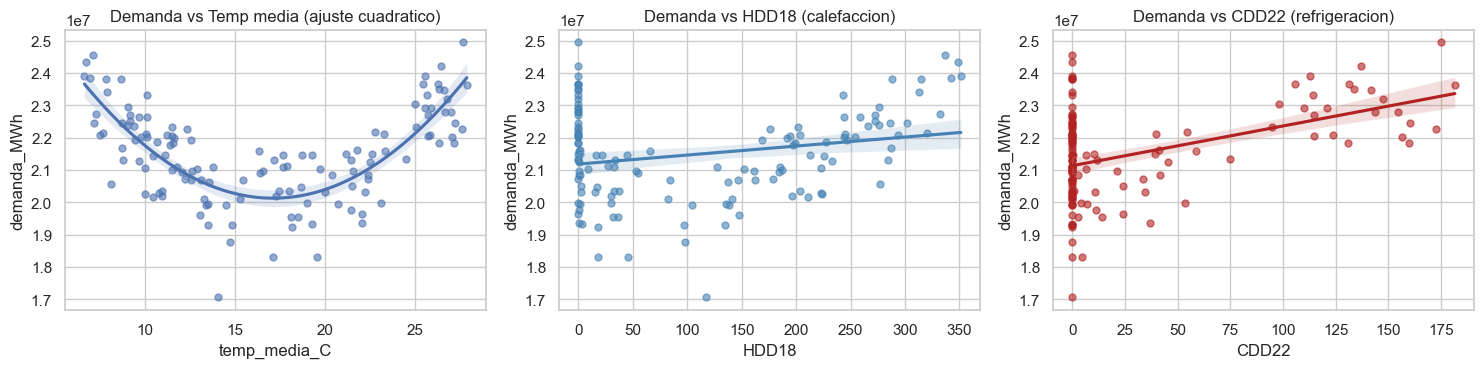

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.regplot(data=df, x='temp_media_C', y='demanda_MWh', order=2,
            ax=axes[0], scatter_kws={'alpha': 0.6, 's': 25})
axes[0].set_title('Demanda vs Temp media (ajuste cuadratico)')
sns.regplot(data=df, x='HDD18', y='demanda_MWh',
            ax=axes[1], scatter_kws={'alpha': 0.6, 's': 25}, color='steelblue')
axes[1].set_title('Demanda vs HDD18 (calefaccion)')
sns.regplot(data=df, x='CDD22', y='demanda_MWh',
            ax=axes[2], scatter_kws={'alpha': 0.6, 's': 25}, color='firebrick')
axes[2].set_title('Demanda vs CDD22 (refrigeracion)')
plt.tight_layout()

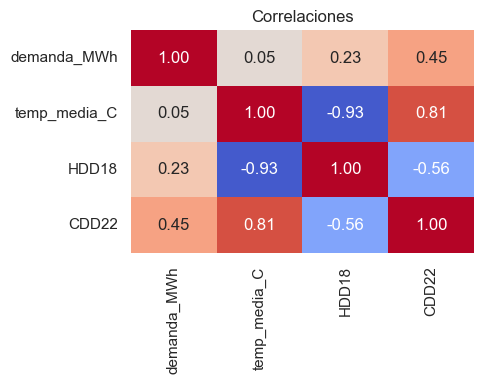

In [8]:
# Matriz de correlacion (Pearson)
corr = df[['demanda_MWh', 'temp_media_C', 'HDD18', 'CDD22']].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar=False)
ax.set_title('Correlaciones')
plt.tight_layout()

## 6. Patrón estacional

### 6a. Por día de la semana (estacionalidad semanal)
Lunes-viernes demanda alta; sábados intermedia; domingos baja.

### 6b. Por mes del año (estacionalidad anual)
Dos picos al año (invierno y verano), valles en primavera/otoño.

In [ ]:
df_plot = df.copy()
df_plot['dia_semana'] = df_plot.index.day_of_week   # 0=lunes, 6=domingo
df_plot['mes']        = df_plot.index.month
df_plot['anio']       = df_plot.index.year

dias_nombre = {0:'Lun', 1:'Mar', 2:'Mie', 3:'Jue', 4:'Vie', 5:'Sab', 6:'Dom'}
df_plot['dia_nombre'] = df_plot['dia_semana'].map(dias_nombre)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Patron semanal
sns.boxplot(data=df_plot, x='dia_semana', y='demanda_MWh', ax=axes[0], color='lightsteelblue',
            order=list(range(7)))
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['Lun','Mar','Mie','Jue','Vie','Sab','Dom'])
axes[0].set_title('Patron semanal (dia de la semana)')
axes[0].set_ylabel('MWh/dia')

# Patron mensual
sns.boxplot(data=df_plot, x='mes', y='demanda_MWh', ax=axes[1], color='lightcoral')
axes[1].set_title('Patron anual (mes del año)')
axes[1].set_ylabel('MWh/dia')

plt.tight_layout()

## 7. Anomalía COVID y totales anuales

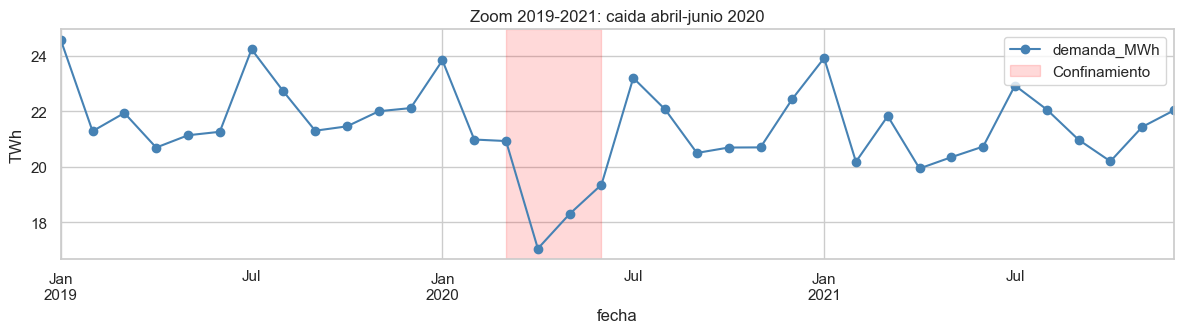

In [10]:
covid = df.loc['2019':'2021', 'demanda_MWh'] / 1e6
fig, ax = plt.subplots(figsize=(12, 3.5))
covid.plot(ax=ax, marker='o', color='steelblue')
ax.axvspan('2020-03-01', '2020-06-30', color='red', alpha=0.15, label='Confinamiento')
ax.set_title('Zoom 2019-2021: caida abril-junio 2020')
ax.set_ylabel('TWh')
ax.legend()
plt.tight_layout()

In [ ]:
anual = df.resample('YE').agg(
    demanda_TWh=('demanda_MWh', lambda x: x.sum() / 1e6),
    HDD_anual=('HDD18', 'sum'),
    CDD_anual=('CDD22', 'sum'),
)
anual.index = anual.index.year
anual['var_yoy_%'] = anual['demanda_TWh'].pct_change() * 100
anual.round(2)

## 8. Conclusiones para el modelado

- Estacionalidad **semanal** fuerte (lag 7): L-V alta, Sáb media, Dom baja → `seasonal_periods = 7` / `m = 7`.
- Estacionalidad **anual** (lag 365): invierno y verano pico, primavera/otoño valle → STL con `period=365`.
- Tendencia con cambio de nivel claro en 2020 (COVID) → **d = 1** o tratamiento explícito de outlier.
- Relación demanda↔temperatura: HDD18 y CDD22 diarios siguen siendo buenos regresores.
- 2020 será el fold más sucio en CV walk-forward (lo reportamos aparte).
- Próximo notebook (`02_modelado.ipynb`): SARIMA(X) con `m=7`, ETS semanal, Prophet con estacionalidades semanal+anual+festivos, CV walk-forward de 4 folds y hold-out 2024-2025.